In [1]:
!pip install -q kagglehub
import kagglehub

In [2]:
path = kagglehub.dataset_download("budincsevity/szeged-weather")

print("Path to dataset files:", path)

100%|██████████| 2.23M/2.23M [00:00<00:00, 62.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/budincsevity/szeged-weather/versions/1


In [3]:
import os
import pandas as pd

# List files in the downloaded directory
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

Files in dataset directory: ['weatherHistory.csv']


Assuming the primary data file is `weatherHistory.csv` (common for this dataset), let's load it into a pandas DataFrame.

In [5]:
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'weatherHistory.csv')

# Load the dataset
df = pd.read_csv(csv_file_path)


In [7]:
# Display the first 5 rows of the DataFrame to confirm import success
display(df.head())

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [18]:
# Transform the dataset to have the X and y variables for our problem
df = df[['Temperature (C)', 'Humidity']]

display(df.head())

,Temperature (C),Humidity
0,9.472222,0.89
1,9.355556,0.86
2,9.377778,0.89
3,8.288889,0.83
4,8.755556,0.83


In [21]:
# Check for any null values
df.isna().sum()

,0
Temperature (C),0
Humidity,0


In [25]:
# Import data preprocessing tool from Scikit-learn libraries
from sklearn.model_selection import train_test_split

X = df[['Humidity']]
y = df['Temperature (C)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 0)

In [27]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

# Train the model on the training dataset
regressor.fit(X_train, y_train)

LinearRegression()

In [28]:
# Predict the test results
y_pred = regressor.predict(X_test)

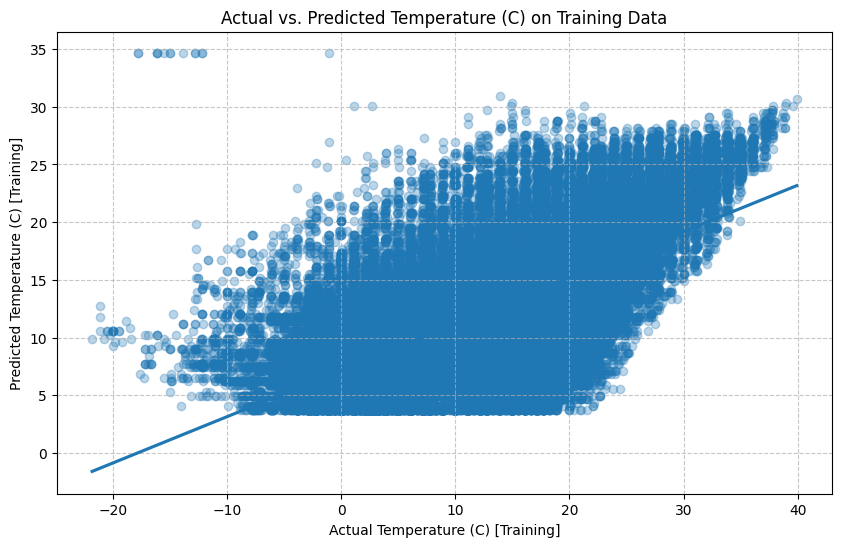

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = regressor.predict(X_train)

plt.figure(figsize=(10, 6))
sns.regplot(x=y_train, y=y_train_pred, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Temperature (C) [Training]')
plt.ylabel('Predicted Temperature (C) [Training]')
plt.title('Actual vs. Predicted Temperature (C) on Training Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

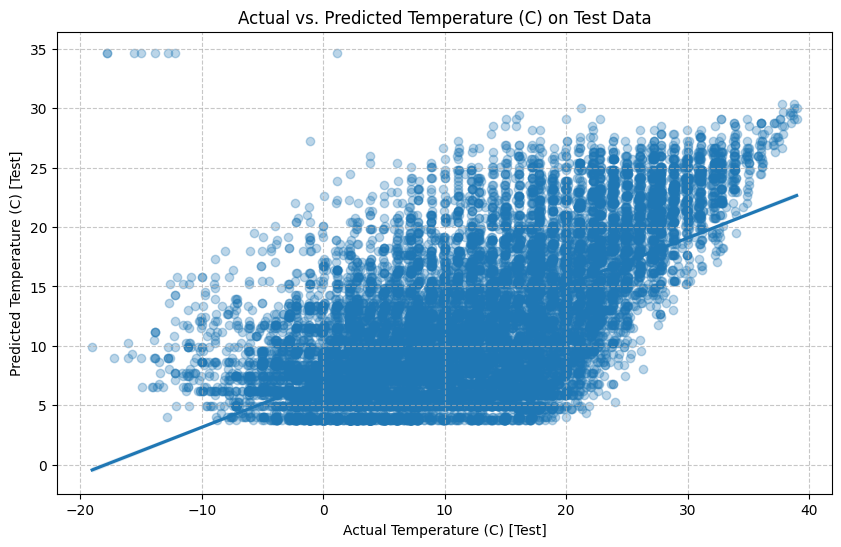

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Temperature (C) [Test]')
plt.ylabel('Predicted Temperature (C) [Test]')
plt.title('Actual vs. Predicted Temperature (C) on Test Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()